# 🏢 Indian Compliance Market Intelligence — A Data-Driven Market Research & Opportunity Analysis using MCA Data
    Source: Ministry of Corporate Affairs

## 📦 Section 1 — Imports & Configuration

In [12]:
# Importing necessary libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import matplotlib.ticker as mticker

## 📂 Data ingestion and data prepration

In [13]:
folder_path = R"D:\Downloads\MCA Data"

csv_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
print(f"Total CSV files: {len(csv_files)}")

all_dfs = []
for file in csv_files:
    df = pd.read_csv(os.path.join(folder_path, file), low_memory=False)
    df['State'] = file.replace('.csv', '')
    all_dfs.append(df)

merged_df = pd.concat(all_dfs, ignore_index=True)
print(f"Shape: {merged_df.shape}")
merged_df.head()

Total CSV files: 37
Shape: (2458152, 17)


,CIN,CompanyName,CompanyROCcode,CompanyCategory,CompanySubCategory,CompanyClass,AuthorizedCapital,PaidupCapital,CompanyRegistrationdate_date,Registered_Office_Address,Listingstatus,CompanyStatus,CompanyStateCode,CompanyIndian/Foreign Company,nic_code,CompanyIndustrialClassification,State
0,U55100AN2009PTC000115,U AND I RESORTS PRIVATE LIMITED,ROC Andaman,Company limited by shares,Non-government company,Private,1000000.0,989630.0,2009-06-18,"HAVELOCK,PORT BLAIR,Andaman and Nicobar Island...",Unlisted,Active,andaman and nicobar islands,Indian,55100,Trading,andaman and nicobar islands
1,U55200AN2021PTC005554,JUNGLEVILLA RESORT & SPA PRIVATE LIMITED,ROC Andaman,Company limited by shares,Non-government company,Private,1500000.0,100000.0,2021-10-13,"C/O BINITH DAS, 01, OPP. GOLDEN PEBBLE GOVIN...",Unlisted,Active,andaman and nicobar islands,Indian,55200,Trading,andaman and nicobar islands
2,U55209AN2018PTC005409,CORAL ISLAND BEACH RESORT PRIVATE LIMITED,ROC Andaman,Company limited by shares,Non-government company,Private,2000000.0,200000.0,2018-05-31,"GOVINDA NAGAR PORT BLAIR SOUTH ANDAMAN,PORT ...",Unlisted,Active,andaman and nicobar islands,Indian,55209,Trading,andaman and nicobar islands
3,U63031AN2019PTC005474,INFO INDIA TOUR AND HOLIDAYS PRIVATE LIMITED,ROC Chennai,Company limited by shares,Non-government company,Private,10000.0,10000.0,2019-11-21,"C/o Kulandai Velu, C-18, V/Nagar Bambooflat,...",Unlisted,Active,andaman and nicobar islands,Indian,63031,"Transport, storage and Communications",andaman and nicobar islands
4,U63040AN1999PTC000061,ANDAMAN TOURIST COTTAGE PRIVATE LIMITED,ROC Andaman,Company limited by shares,Non-government company,Private,1000000.0,10000.0,1999-04-26,"Babu Lane Port Blair,NA,Andaman and Nicobar ...",Unlisted,Strike Off,andaman and nicobar islands,Indian,63040,"Transport, storage and Communications",andaman and nicobar islands


In [14]:
# Reference columns from first file
first_file_path = os.path.join(folder_path, csv_files[0])
reference_columns = list(pd.read_csv(first_file_path, nrows=0).columns)

mismatch_files = []

for file in csv_files:
    file_path = os.path.join(folder_path, file)
    columns = list(pd.read_csv(file_path, nrows=0).columns)

    if columns != reference_columns:
        mismatch_files.append(file)

# Final result
if len(mismatch_files) == 0:
    print("✅ All CSV files have the same columns")
else:
    print("❌ Files with different columns:")
    for file in mismatch_files:
        print(file)

✅ All CSV files have the same columns


In [15]:
all_dfs = []

for file in csv_files:
    
    file_path = os.path.join(folder_path, file)
    
    df = pd.read_csv(file_path, low_memory=False)
    
    state_name = file.replace(".csv", "")
    df["State"] = state_name
    
    all_dfs.append(df)

merged_df = pd.concat(all_dfs, ignore_index=True)

print("Total rows:", len(merged_df))
print("Total columns:", merged_df.shape[1])

Total rows: 2458152
Total columns: 17


In [16]:
merged_df.head()

,CIN,CompanyName,CompanyROCcode,CompanyCategory,CompanySubCategory,CompanyClass,AuthorizedCapital,PaidupCapital,CompanyRegistrationdate_date,Registered_Office_Address,Listingstatus,CompanyStatus,CompanyStateCode,CompanyIndian/Foreign Company,nic_code,CompanyIndustrialClassification,State
0,U55100AN2009PTC000115,U AND I RESORTS PRIVATE LIMITED,ROC Andaman,Company limited by shares,Non-government company,Private,1000000.0,989630.0,2009-06-18,"HAVELOCK,PORT BLAIR,Andaman and Nicobar Island...",Unlisted,Active,andaman and nicobar islands,Indian,55100,Trading,andaman and nicobar islands
1,U55200AN2021PTC005554,JUNGLEVILLA RESORT & SPA PRIVATE LIMITED,ROC Andaman,Company limited by shares,Non-government company,Private,1500000.0,100000.0,2021-10-13,"C/O BINITH DAS, 01, OPP. GOLDEN PEBBLE GOVIN...",Unlisted,Active,andaman and nicobar islands,Indian,55200,Trading,andaman and nicobar islands
2,U55209AN2018PTC005409,CORAL ISLAND BEACH RESORT PRIVATE LIMITED,ROC Andaman,Company limited by shares,Non-government company,Private,2000000.0,200000.0,2018-05-31,"GOVINDA NAGAR PORT BLAIR SOUTH ANDAMAN,PORT ...",Unlisted,Active,andaman and nicobar islands,Indian,55209,Trading,andaman and nicobar islands
3,U63031AN2019PTC005474,INFO INDIA TOUR AND HOLIDAYS PRIVATE LIMITED,ROC Chennai,Company limited by shares,Non-government company,Private,10000.0,10000.0,2019-11-21,"C/o Kulandai Velu, C-18, V/Nagar Bambooflat,...",Unlisted,Active,andaman and nicobar islands,Indian,63031,"Transport, storage and Communications",andaman and nicobar islands
4,U63040AN1999PTC000061,ANDAMAN TOURIST COTTAGE PRIVATE LIMITED,ROC Andaman,Company limited by shares,Non-government company,Private,1000000.0,10000.0,1999-04-26,"Babu Lane Port Blair,NA,Andaman and Nicobar ...",Unlisted,Strike Off,andaman and nicobar islands,Indian,63040,"Transport, storage and Communications",andaman and nicobar islands


In [17]:
merged_df.shape #(rows, columns)

(2458152, 17)

In [18]:
merged_df.columns #List of column names

Index(['CIN', 'CompanyName', 'CompanyROCcode', 'CompanyCategory',
       'CompanySubCategory', 'CompanyClass', 'AuthorizedCapital',
       'PaidupCapital', 'CompanyRegistrationdate_date',
       'Registered_Office_Address', 'Listingstatus', 'CompanyStatus',
       'CompanyStateCode', 'CompanyIndian/Foreign Company', 'nic_code',
       'CompanyIndustrialClassification', 'State'],
      dtype='object')

In [19]:
merged_df.info() #data types and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2458152 entries, 0 to 2458151
Data columns (total 17 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   CIN                              object 
 1   CompanyName                      object 
 2   CompanyROCcode                   object 
 3   CompanyCategory                  object 
 4   CompanySubCategory               object 
 5   CompanyClass                     object 
 6   AuthorizedCapital                float64
 7   PaidupCapital                    float64
 8   CompanyRegistrationdate_date     object 
 9   Registered_Office_Address        object 
 10  Listingstatus                    object 
 11  CompanyStatus                    object 
 12  CompanyStateCode                 object 
 13  CompanyIndian/Foreign Company    object 
 14  nic_code                         object 
 15  CompanyIndustrialClassification  object 
 16  State                            object 
dtypes: float

In [20]:
# Converting 'CompanyRegistrationdate_date' to datetime format

merged_df['CompanyRegistrationdate_date'] = pd.to_datetime(merged_df['CompanyRegistrationdate_date'], format='%Y-%m-%d')

In [21]:
# Checking for missing values in the merged DataFrame

merged_df.isnull().sum()

CIN                                 0
CompanyName                         0
CompanyROCcode                      0
CompanyCategory                     0
CompanySubCategory                  0
CompanyClass                        0
AuthorizedCapital                   0
PaidupCapital                       0
CompanyRegistrationdate_date        0
Registered_Office_Address          60
Listingstatus                       0
CompanyStatus                       0
CompanyStateCode                    0
CompanyIndian/Foreign Company       0
nic_code                            0
CompanyIndustrialClassification     0
State                               0
dtype: int64

In [29]:
# checking why registerd office address is null

nulls = merged_df[merged_df.isnull().any(axis=1)]
nulls.head()

,CIN,CompanyName,CompanyROCcode,CompanyCategory,CompanySubCategory,CompanyClass,AuthorizedCapital,PaidupCapital,CompanyRegistrationdate_date,Registered_Office_Address,Listingstatus,CompanyStatus,CompanyStateCode,CompanyIndian/Foreign Company,nic_code,CompanyIndustrialClassification,State,YearMonth
38205,U51909AP2021PTC120033,TERRANOVA GREEN ENERGY PRIVATE LIMITED,ROC Vijayawada,Company limited by shares,Non-government company,Private,20000000.0,10000000.0,2021-11-12,NaN,Unlisted,Active,andhra pradesh,Indian,51909.0,Trading,andhra pradesh,2021-11
185820,U02423DL1994PTC060357,SUPERMAG DRUGS PVT LTD,ROC Delhi,Company limited by shares,Non-government company,Private,100000.0,0.0,1994-07-19,NaN,Unlisted,Strike Off,delhi,Indian,2423,Agriculture and Allied Activities,delhi,1994-07
240729,U17290GJ2005PLC046345,PRADIP OVERSEAS LIMITED,ROC Ahmedabad,Company limited by shares,Non-government company,Public,900000000.0,1400000.0,2005-06-29,NaN,Unlisted,Active,gujarat,Indian,17290,"Manufacturing (Paper and Paper products, Publi...",gujarat,2005-06
325591,U21000GJ2020PTC116603,SUNRAYS PACKAGING PRIVATE LIMITED,ROC Ahmedabad,Company limited by shares,Non-government company,Private,100000.0,100000.0,2020-09-17,NaN,Unlisted,Active,gujarat,Indian,21000,"Manufacturing (Paper and Paper products, Publi...",gujarat,2020-09
358300,U85500HR2023PTC109658,SKY4U CONNOISSEUR PRIVATE LIMITED,ROC Delhi,Company limited by shares,Non-government company,Private,1000000.0,100000.0,2023-02-28,NaN,Unlisted,Active,haryana,Indian,85500,"Community, personal and Social Services",haryana,2023-02


In [30]:
# Check for duplicates in the 'CIN' column
duplicate_count = merged_df['CIN'].duplicated().sum()
print(f"Number of duplicate CINs: {duplicate_count}")

if duplicate_count > 0:
    print("There are duplicate CINs in the dataset.")
else:
    print("No duplicate CINs found.")

Number of duplicate CINs: 64813
There are duplicate CINs in the dataset.


In [33]:
duplicated_cin_df = merged_df[merged_df['CIN'].duplicated(keep=False)]
duplicated_cin_df.head(50)

,CIN,CompanyName,CompanyROCcode,CompanyCategory,CompanySubCategory,CompanyClass,AuthorizedCapital,PaidupCapital,CompanyRegistrationdate_date,Registered_Office_Address,Listingstatus,CompanyStatus,CompanyStateCode,CompanyIndian/Foreign Company,nic_code,CompanyIndustrialClassification,State,YearMonth
960154,U52390MH2022PTC380655,GROWONS HYPERMARKET PRIVATE LIMITED,ROC Mumbai,Company limited by shares,Non-government company,Private,100000.0,100000.0,2022-04-18,"32, Floor- GRD,87, Shrinbai Chawl Mohammed S...",Unlisted,Active,maharashtra,Indian,52390,Trading,maharastra,2022-04
960157,U92312MH2014PTC255385,MOTHER'S EYE PRODUCTION PRIVATE LIMITED,ROC Mumbai,Company limited by shares,Non-government company,Private,100000.0,100000.0,2014-06-05,"702, 7th Floor, Lotus Trade Centre New Link ...",Unlisted,Active,maharashtra,Indian,92312,"Community, personal and Social Services",maharastra,2014-06
960158,U92320MH2013PTC249355,SPORTS FOR LIFE EDUCATION PRIVATE LIMITED,ROC Mumbai,Company limited by shares,Non-government company,Private,300000.0,100000.0,2013-10-18,"1003, Rosa Alba, Nahar Amrit Shakti Andheri ...",Unlisted,Active,maharashtra,Indian,92320,"Community, personal and Social Services",maharastra,2013-10
960159,U92330PN2011PTC141330,IDNA GRAPHICS PRIVATE LIMITED,ROC Pune,Company limited by shares,Non-government company,Private,2000000.0,100000.0,2011-11-11,"BLDG A-2 FLAT NO 1&2, DHAN-LAXMI PARK, S NO 97...",Unlisted,Strike Off,maharashtra,Indian,92330,"Community, personal and Social Services",maharastra,2011-11
960161,U92400MH2003PLC142390,DATTA MEGHE HEALTH CLUB LIMITED,ROC Mumbai,Company limited by guarantee,Non-government company,Public,0.0,0.0,2003-09-26,DATTA MEGHEAT POST-SAWANGI MEGHE DISTRICT-WA...,Unlisted,Strike Off,maharashtra,Indian,92400,"Community, personal and Social Services",maharastra,2003-09
960163,U92400MH2010PTC211525,OMG MOVIE WORLD PRIVATE LIMITED,ROC Mumbai,Company limited by shares,Non-government company,Private,5000000.0,100000.0,2010-12-28,"210, SURGAM BUNGLOW SOCEITY NO. 54 S V P NAG...",Unlisted,Strike Off,maharashtra,Indian,92400,"Community, personal and Social Services",maharastra,2010-12
960165,U72300MH2012PTC235517,WEB COOL NET PRIVATE LIMITED,ROC Mumbai,Company limited by shares,Non-government company,Private,100000.0,100000.0,2012-09-10,"Flat No.603,B-67,Sector No.01,Shanti Nagar, ...",Unlisted,Strike Off,maharashtra,Indian,72300,Business Services,maharastra,2012-09
960169,U92410MH1998PTC114146,THAKUR HEALTH CARE CENTER PRIVATE LIMITED,ROC Mumbai,Company limited by shares,Non-government company,Private,500000.0,100000.0,1998-03-25,"NAV KRISHNA KUNJDATTA NAGAR DOMBIVLI EAST,TH...",Unlisted,Active,maharashtra,Indian,92410,"Community, personal and Social Services",maharastra,1998-03
960170,U72300MH2013FTC248980,BROCADE MOBILITY PRIVATE LIMITED,ROC Mumbai,Company limited by shares,subsidiary of company incorporated outside India,Private,105500000.0,105500000.0,2013-10-08,"701, The Capital, Level 7 Bandra Kurla compl...",Unlisted,Active,maharashtra,Indian,72300,Business Services,maharastra,2013-10
960171,U92410MH2000NPL128424,WESTERN INDIA SPORTS ASSOCIATION,ROC Mumbai,Company limited by guarantee,Non-government company,Private,0.0,0.0,2000-08-24,"SHOP NO 2, GALAXY APARTMENT, OPPOSITE TIROPATI...",Unlisted,Active,maharashtra,Indian,92410,"Community, personal and Social Services",maharastra,2000-08


In [36]:
# Sort duplicated_cin_df by CIN to group duplicates together
duplicated_cin_df = duplicated_cin_df.sort_values(by='CIN')
duplicated_cin_df.head(50)

,CIN,CompanyName,CompanyROCcode,CompanyCategory,CompanySubCategory,CompanyClass,AuthorizedCapital,PaidupCapital,CompanyRegistrationdate_date,Registered_Office_Address,Listingstatus,CompanyStatus,CompanyStateCode,CompanyIndian/Foreign Company,nic_code,CompanyIndustrialClassification,State,YearMonth
962405,L01100MH1990PLC055860,WHITE ORGANIC AGRO LIMITED,ROC Mumbai,Company limited by shares,Non-government company,Public,7.000000e+08,3.500000e+08,1990-03-19,"312A, KAILAS PLAZA, VALLABH BAUG LANE, GHATK...",Listed,Active,maharashtra,Indian,01100,Agriculture and Allied Activities,maharastra,1990-03
971852,L01100MH1990PLC055860,WHITE ORGANIC AGRO LIMITED,ROC Mumbai,Company limited by shares,Non-government company,Public,7.000000e+08,3.500000e+08,1990-03-19,"312A, KAILAS PLAZA, VALLABH BAUG LANE, GHATK...",Listed,Active,maharashtra,Indian,01100,Agriculture and Allied Activities,maharastra,1990-03
1079951,L01110MH1993PLC073268,AGRI-TECH (INDIA) LIMITED,ROC Mumbai,Company limited by shares,Non-government company,Public,8.250000e+07,5.940000e+07,1993-08-02,"NATH HOUSE NATH ROAD,AURANGABAD,Aurangabad,M...",Listed,Active,maharashtra,Indian,01110,Agriculture and Allied Activities,maharastra,1993-08
1171477,L01110MH1993PLC073268,AGRI-TECH (INDIA) LIMITED,ROC Mumbai,Company limited by shares,Non-government company,Public,8.250000e+07,5.940000e+07,1993-08-02,"NATH HOUSE NATH ROAD,AURANGABAD,Aurangabad,M...",Listed,Active,maharashtra,Indian,01110,Agriculture and Allied Activities,maharastra,1993-08
1079952,L01111MH1985PLC228508,SHALIMAR PRODUCTIONS LIMITED,ROC Mumbai,Company limited by shares,Non-government company,Public,1.500000e+09,9.843283e+08,1985-03-20,"A-9, Shree Siddhivinayak Plaza, Plot No. B-31,...",Listed,Active,maharashtra,Indian,01111,Agriculture and Allied Activities,maharastra,1985-03
1171478,L01111MH1985PLC228508,SHALIMAR PRODUCTIONS LIMITED,ROC Mumbai,Company limited by shares,Non-government company,Public,1.500000e+09,9.843283e+08,1985-03-20,"A-9, Shree Siddhivinayak Plaza, Plot No. B-31,...",Listed,Active,maharashtra,Indian,01111,Agriculture and Allied Activities,maharastra,1985-03
1332641,L01130MH1990PLC056285,CAVENDISH AGRO MILLS LIMITED,ROC Mumbai,Company limited by shares,Non-government company,Public,5.000000e+06,0.000000e+00,1990-04-23,"SAMMIJRA COLONY NEAR REGIONALWORKSHOP,NANDED,...",Listed,Strike Off,maharashtra,Indian,01130,Agriculture and Allied Activities,maharastra,1990-04
1356266,L01130MH1990PLC056285,CAVENDISH AGRO MILLS LIMITED,ROC Mumbai,Company limited by shares,Non-government company,Public,5.000000e+06,0.000000e+00,1990-04-23,"SAMMIJRA COLONY NEAR REGIONALWORKSHOP,NANDED,...",Listed,Strike Off,maharashtra,Indian,01130,Agriculture and Allied Activities,maharastra,1990-04
1066441,L07295MH1991PLC243430,UNISTAR MULTIMEDIA LIMITED,ROC Mumbai,Company limited by shares,Non-government company,Public,5.100000e+08,2.500070e+08,1991-04-08,"SH 187, Powai Plaza MTRII CST NS Hiranandani,B...",Listed,Active,maharashtra,Indian,07295,Mining and Quarrying,maharastra,1991-04
971854,L07295MH1991PLC243430,UNISTAR MULTIMEDIA LIMITED,ROC Mumbai,Company limited by shares,Non-government company,Public,5.100000e+08,2.500070e+08,1991-04-08,"SH 187, Powai Plaza MTRII CST NS Hiranandani,B...",Listed,Active,maharashtra,Indian,07295,Mining and Quarrying,maharastra,1991-04


In [37]:
merged_df.duplicated().sum()

np.int64(64813)

In [38]:
# Drop duplicates based on CIN and create a new dataframe
ndf = merged_df.drop_duplicates(subset=['CIN'], keep='first').reset_index(drop=True)

print(f"Original dataframe shape: {merged_df.shape}")
print(f"New dataframe shape (after removing duplicates): {ndf.shape}")
print(f"Duplicates removed: {merged_df.shape[0] - ndf.shape[0]}")

Original dataframe shape: (2458152, 18)
New dataframe shape (after removing duplicates): (2393339, 18)
Duplicates removed: 64813


In [43]:
ndf['CompanyStatus'].unique() #get unique values in the 'CompanyStatus' column

array(['Active', 'Strike Off', 'Under Liquidation',
       'Under process of striking off', 'Dormant under section 455',
       'Amalgamated', 'Converted to LLP', 'Dissolved (Liquidated)',
       'Inactive for e-filing', 'Under CIRP',
       'Dissolved under section 59(8)', 'Strike Off-AwaitingPublication',
       'Dissolved under section 54', 'Vanished', 'Dissolved',
       'Not available for efiling', 'Converted to LLP and Dissolved',
       'Inactive', 'Unclassified'], dtype=object)

# 📊 EDA (Exporatory data analysis)

## Market sizing — how big is the opportunity?

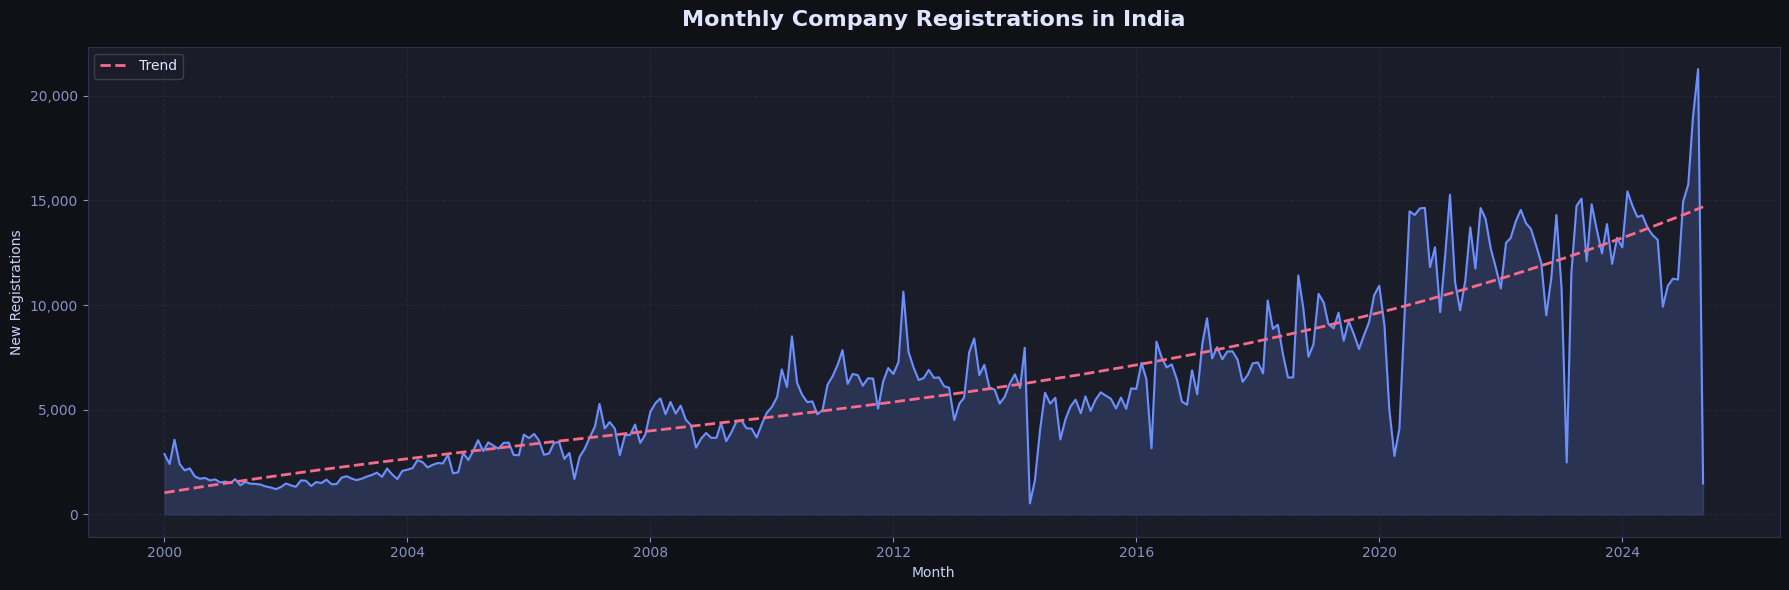

In [39]:
# ── Parse dates & extract month ────────────────────────────────────
ndf['CompanyRegistrationdate_date'] = pd.to_datetime(
    ndf['CompanyRegistrationdate_date'], errors='coerce'
)
ndf['YearMonth'] = ndf['CompanyRegistrationdate_date'].dt.to_period('M')
 
# ── Monthly count ──────────────────────────────────────────────────
monthly = (
    ndf.groupby('YearMonth')
    .size()
    .reset_index(name='Registrations')
    .sort_values('YearMonth')
)
monthly['YearMonth_dt'] = monthly['YearMonth'].dt.to_timestamp()
 
# ── Filter to 2000 onwards for clarity (adjust if needed) ──────────
monthly = monthly[monthly['YearMonth_dt'] >= '2000-01-01']
 
# ── Plot ───────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#2e3250',
    'axes.labelcolor':  '#c9d1f5',
    'xtick.color':      '#8892c4',
    'ytick.color':      '#8892c4',
    'text.color':       '#e0e6ff',
    'grid.color':       '#2e3250',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
})
 
fig, ax = plt.subplots(figsize=(18, 6))
 
ax.fill_between(monthly['YearMonth_dt'], monthly['Registrations'],
                alpha=0.2, color='#6c8fff')
ax.plot(monthly['YearMonth_dt'], monthly['Registrations'],
        color='#6c8fff', linewidth=1.5)
 
# ── Trend line (polynomial degree 3) ──────────────────────────────
x_numeric = np.arange(len(monthly))
z = np.polyfit(x_numeric, monthly['Registrations'], 3)
p = np.poly1d(z)
ax.plot(monthly['YearMonth_dt'], p(x_numeric),
        color='#f76c8a', linewidth=2, linestyle='--', label='Trend')
ax.legend(fontsize=10, framealpha=0.2)
 
ax.set_title('Monthly Company Registrations in India', fontsize=16,
             fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('New Registrations')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(True)
 
plt.tight_layout()
plt.show()

Market size can be defined across multiple layers—Total Addressable Market (TAM), Serviceable Available Market (SAM), and Serviceable Obtainable Market (SOM). In this analysis, company-level data will be used to estimate market size across these dimensions. Due to the absence of direct revenue data, Paid-up Capital will be considered as a proxy for economic activity and company scale. The dataset will be segmented based on company status, industry classification, company type, and registration trends to identify high-potential segments and actionable opportunities. This structured approach will enable a comprehensive understanding of the overall market landscape while helping identify the most relevant and monetizable target segments for business expansion.

In [23]:
print("TAM (Total Addressable Market):", merged_df['CIN'].nunique())
print("SAM (Serviceable Available Market):", merged_df[merged_df['CompanyStatus'] == 'Active']['CIN'].nunique())

TAM (Total Addressable Market): 2393339
SAM (Serviceable Available Market): 1582271


In [24]:
merged_df.columns

Index(['CIN', 'CompanyName', 'CompanyROCcode', 'CompanyCategory',
       'CompanySubCategory', 'CompanyClass', 'AuthorizedCapital',
       'PaidupCapital', 'CompanyRegistrationdate_date',
       'Registered_Office_Address', 'Listingstatus', 'CompanyStatus',
       'CompanyStateCode', 'CompanyIndian/Foreign Company', 'nic_code',
       'CompanyIndustrialClassification', 'State', 'YearMonth'],
      dtype='object')